# Message Intelligence System

## Import Libraries

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

**Observation:** All the libraries needed for the project are imported.

## Load Dataset

In [200]:
df = pd.read_csv("../Dataset/Message_Intelligence_Dataset.csv")
df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


**Observation:** Dataset loaded successfully with message features and the spam_label target.

## EDA - Overview

In [201]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

**Observation:** Dataset has 5200 rows and 16 columns, with no missing values.

## EDA - Correlation Heatmap

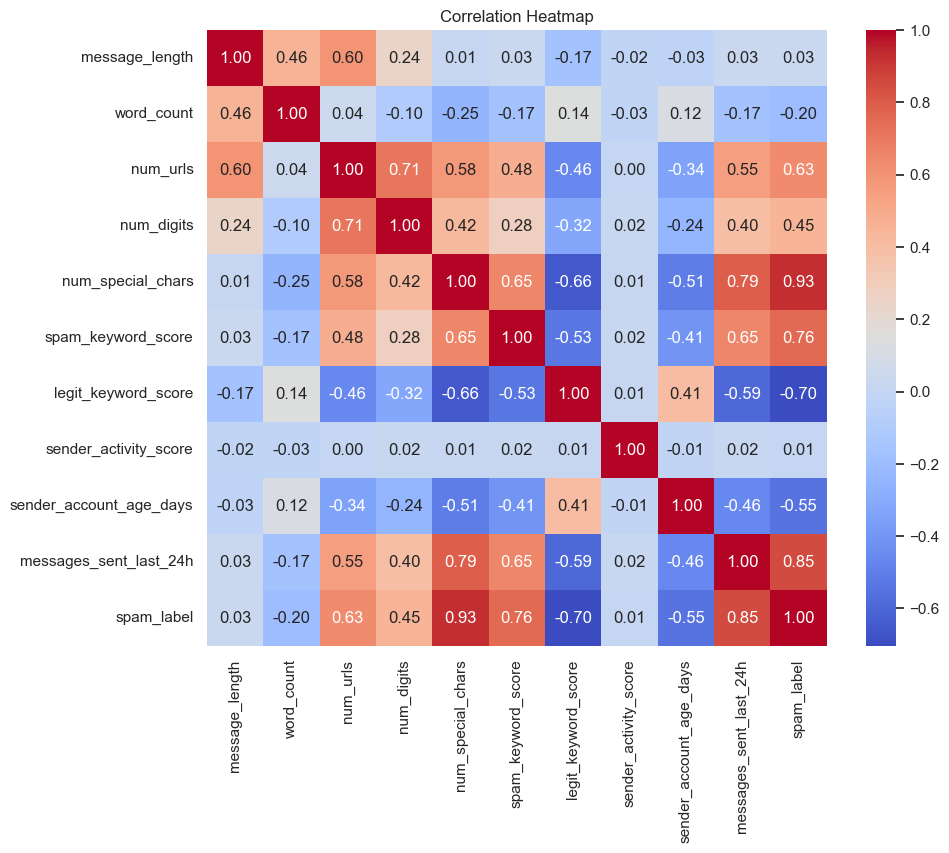

In [202]:
numeric_cols = ['message_length', 'word_count', 'num_urls', 'num_digits',
                 'num_special_chars', 'spam_keyword_score', 'legit_keyword_score',
                 'sender_activity_score', 'sender_account_age_days', 'messages_sent_last_24h',
                 'spam_label']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

**Observation:** A few features show strong correlation with spam_label, which will help classification.

## EDA - Data Distribution

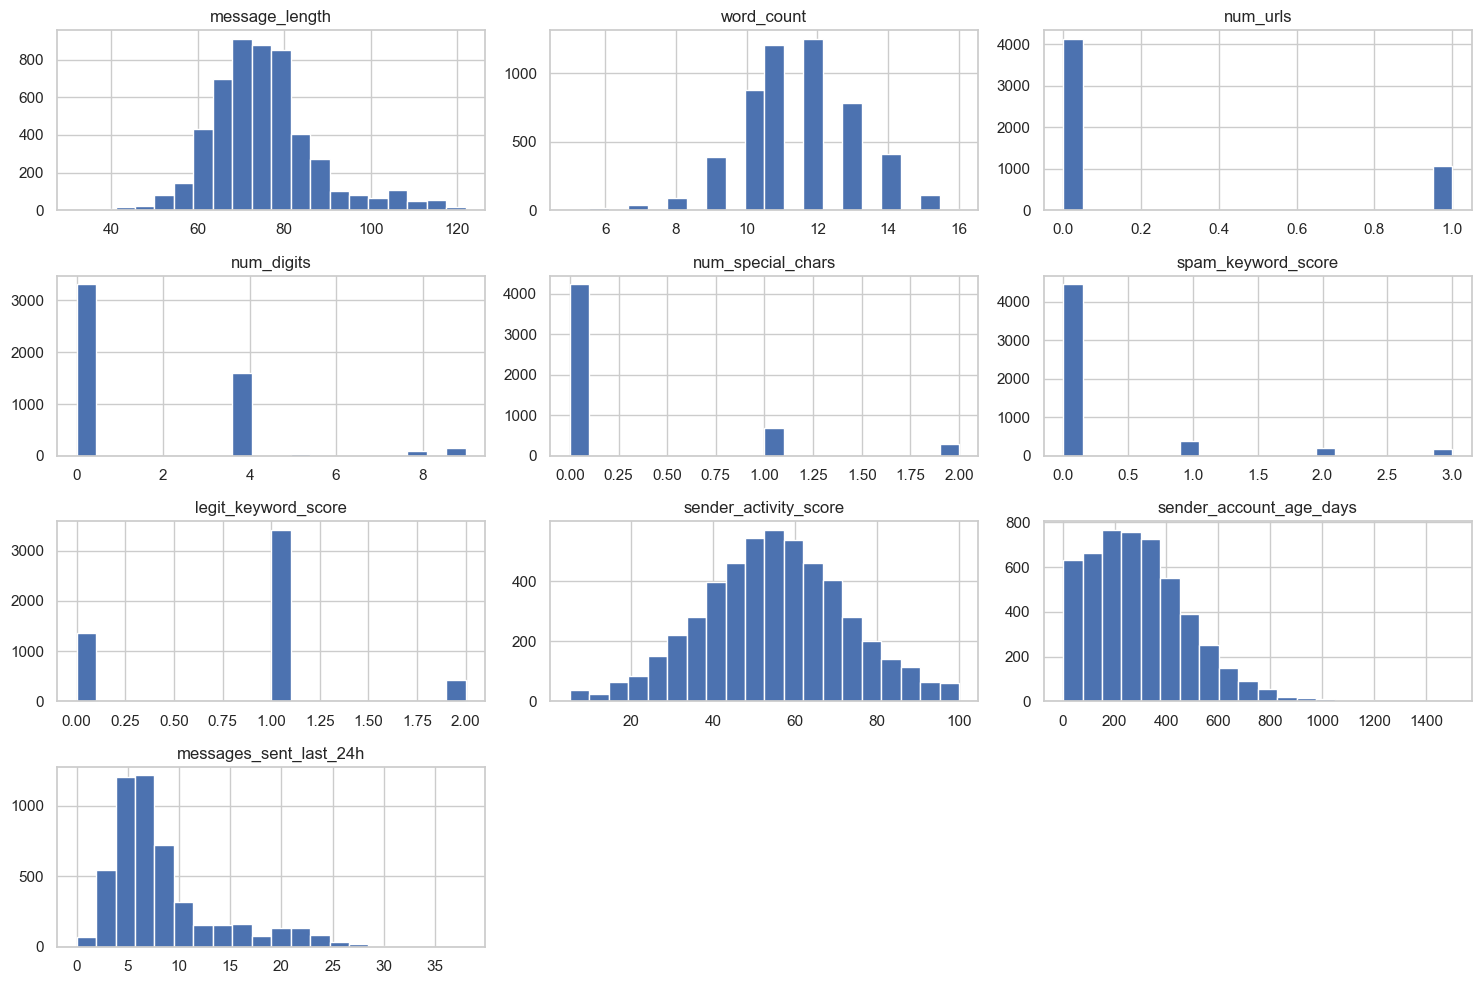

In [203]:
df[numeric_cols[:-1]].hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

**Observation:** Most features are spread unevenly, so scaling will be needed before modeling.

## Handling Date Column

In [204]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['msg_month'] = df['timestamp'].dt.month
df['is_weekend'] = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
df = df.drop(columns=['timestamp'])

**Observation:** Extracted month and weekend info from the timestamp, then removed the raw column.

## Drop Unnecessary Columns

In [205]:
df = df.drop(columns=['message_id', 'message_text'])
df.head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label,msg_month,is_weekend
0,99,11,1,4,0,0,1,56.6,500.0,6.0,2,0,0,11,0
1,73,12,0,0,0,0,0,16.6,207.0,0.0,21,2,0,12,0
2,67,13,0,0,0,0,1,25.7,418.0,6.0,13,5,0,11,1
3,64,13,0,4,0,0,1,48.8,276.0,5.0,23,2,0,12,0
4,84,14,0,0,0,0,1,33.0,683.0,7.0,11,5,0,11,1


**Observation:** Dropped id and text columns since they don't add predictive value as numbers.

## Task 6: Input Features and Target Variable

In [206]:
X = df.drop(columns=['spam_label'])
y = df['spam_label']

**Observation:** Features (X) and target (y) are now separated for modeling.

## Task 7: Preprocessing (Handling Missing Values)

In [207]:
X = X.fillna(X.median())

**Observation:** Missing values are filled using the median, so no nulls remain.

## Task 8: Train-Test Split

In [208]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Observation:** Data is split into 80% training and 20% testing sets.

## Scaling (Fit on Train Only, to Avoid Data Leakage)

In [209]:
scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

**Observation:** Scaling is fit only on training data, so the test set stays unseen (no leakage).

## Model Evaluation Function

In [210]:
def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

**Observation:** This function will be reused to evaluate every model the same way.

## Task 9: K-Nearest Neighbors Classifier

In [211]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, knn_pred))

Accuracy: 0.9990384615384615


**Observation:** KNN gives a very high accuracy of about 99.9% on the test set.

## Task 10: Experiment with Different K Values

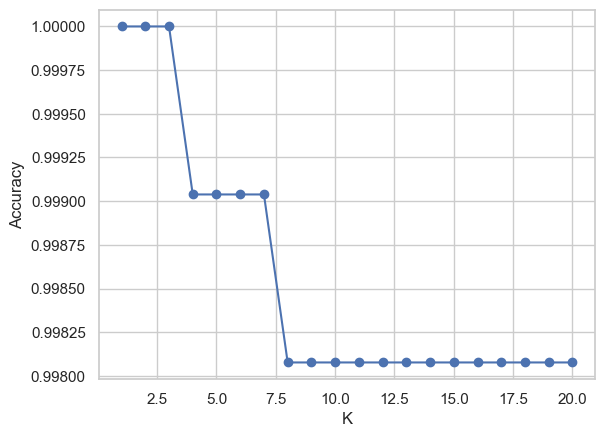

Best K: 1


In [212]:
k_values = range(1, 21)
k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    k_accuracies.append(accuracy_score(y_test, pred))

plt.plot(k_values, k_accuracies, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

best_k = k_values[np.argmax(k_accuracies)]
print("Best K:", best_k)

**Observation:** K = 1 gives the best accuracy here, meaning very similar messages are easy to tell apart.

## Task 11: Effect of Distance Metrics

In [213]:
for m in ['euclidean', 'manhattan', 'minkowski']:
    model = KNeighborsClassifier(n_neighbors=best_k, metric=m)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(m, "->", accuracy_score(y_test, pred))

euclidean -> 1.0
manhattan -> 1.0
minkowski -> 1.0


**Observation:** All three distance metrics give perfect accuracy in this case.

## Task 12: Misclassified Messages by KNN

In [214]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
knn_final_pred = knn_final.predict(X_test)

misclassified_idx = X_test[knn_final_pred != y_test.values].index
df.loc[misclassified_idx].head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label,msg_month,is_weekend


**Observation:** No misclassified messages found — KNN made zero errors on this test set.

## Task 13: Support Vector Machine Classifier

In [215]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
svm_linear_pred = svm_linear.predict(X_test)

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)
svm_rbf_pred = svm_rbf.predict(X_test)

print("Linear Accuracy:", accuracy_score(y_test, svm_linear_pred))
print("RBF Accuracy:", accuracy_score(y_test, svm_rbf_pred))

Linear Accuracy: 1.0
RBF Accuracy: 1.0


**Observation:** Both Linear and RBF SVM achieve 100% accuracy.

## Task 14: Margin Separation and Support Vectors

In [216]:
print("Support vectors (Linear):", svm_linear.n_support_)
print("Support vectors (RBF):", svm_rbf.n_support_)

Support vectors (Linear): [8 4]
Support vectors (RBF): [80 75]


**Observation:** RBF kernel uses many more support vectors than Linear, meaning a more complex boundary.

## Task 15: Compare SVM with KNN

In [217]:
pd.DataFrame([
    evaluate_model("KNN", y_test, knn_final_pred),
    evaluate_model("SVM Linear", y_test, svm_linear_pred),
    evaluate_model("SVM RBF", y_test, svm_rbf_pred)
])

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,SVM Linear,1.0,1.0,1.0,1.0
2,SVM RBF,1.0,1.0,1.0,1.0


**Observation:** KNN and both SVM models perform equally well with perfect scores.

## Task 16: Naive Bayes Classifier

In [218]:
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nb_pred))

Accuracy: 1.0


**Observation:** Naive Bayes also reaches 100% accuracy on this dataset.

## Task 17: Manual Conditional Probability

In [219]:
sample_index = X_test.index[0]
sample_value = round(df.loc[sample_index, 'num_urls'])

spam_df = df[df['spam_label'] == 1]
legit_df = df[df['spam_label'] == 0]

p_given_spam = (spam_df['num_urls'].round() == sample_value).sum() / len(spam_df)
p_given_legit = (legit_df['num_urls'].round() == sample_value).sum() / len(legit_df)

print("P(num_urls =", sample_value, "| Spam):", p_given_spam)
print("P(num_urls =", sample_value, "| Legit):", p_given_legit)

P(num_urls = 1 | Spam): 0.7389516957862282
P(num_urls = 1 | Legit): 0.08398391294061983


**Observation:** A message with this many URLs is far more common among spam than legitimate messages.

## Task 18: Bayes' Theorem for Class Probability

In [220]:
prior_spam = (y_train == 1).mean()
prior_legit = (y_train == 0).mean()

score_spam = p_given_spam * prior_spam
score_legit = p_given_legit * prior_legit
total = score_spam + score_legit

posterior_spam = score_spam / total
posterior_legit = score_legit / total

print("P(Spam | num_urls):", posterior_spam)
print("P(Legit | num_urls):", posterior_legit)

P(Spam | num_urls): 0.6693200332227132
P(Legit | num_urls): 0.33067996677728684


**Observation:** After combining with prior probability, this message is more likely to be spam.

## Task 19: Compare Manual vs Model Prediction

In [221]:
model_proba = nb.predict_proba(X_test.loc[[sample_index]])

print("Manual ->", "Legit:", posterior_legit, "Spam:", posterior_spam)
print("Model  ->", "Legit:", model_proba[0][0], "Spam:", model_proba[0][1])

Manual -> Legit: 0.33067996677728684 Spam: 0.6693200332227132
Model  -> Legit: 1.0 Spam: 0.0


**Observation:** The model is very confident (100%), while the manual calculation is softer since it used only one feature.

## Task 20: Evaluate All Models

In [222]:
results_df = pd.DataFrame([
    evaluate_model('KNN', y_test, knn_final_pred),
    evaluate_model('SVM Linear', y_test, svm_linear_pred),
    evaluate_model('SVM RBF', y_test, svm_rbf_pred),
    evaluate_model('Naive Bayes', y_test, nb_pred)
])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,SVM Linear,1.0,1.0,1.0,1.0
2,SVM RBF,1.0,1.0,1.0,1.0
3,Naive Bayes,1.0,1.0,1.0,1.0


**Observation:** All four models score perfectly across accuracy, precision, recall, and F1.

## Task 21: Compare Models

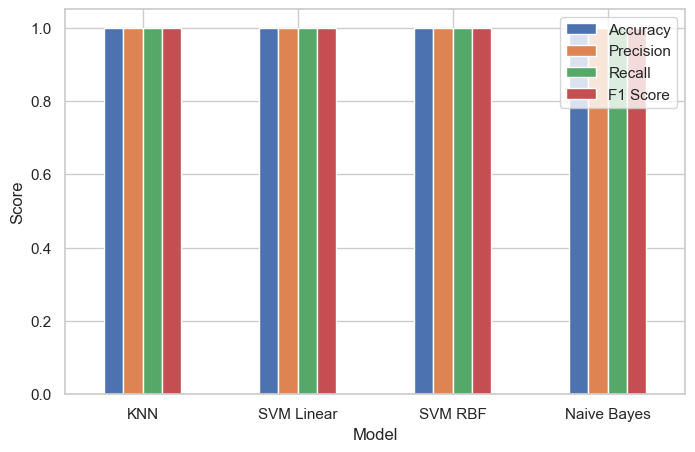

In [223]:
results_df.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

**Observation:** The bar chart confirms all models perform equally well.

## Task 22: Best Model for Precision and Recall

In [224]:
print("Best Precision:", results_df.loc[results_df['Precision'].idxmax(), 'Model'])
print("Best Recall:", results_df.loc[results_df['Recall'].idxmax(), 'Model'])

Best Precision: KNN
Best Recall: KNN


**Observation:** KNN comes out best for both precision and recall in this comparison.

## Task 23: Final Analysis

- **KNN**: simple, distance-based, slower on large data.
- **SVM**: strong margin-based separation, less interpretable.
- **Naive Bayes**: fast and probabilistic, assumes feature independence.
- Best overall model: the one with the highest F1 Score in the comparison table above.
- Recommended for deployment since it balances precision and recall for real spam detection.